# Building Your First AI Agent — for the Lab
### A hands-on notebook

Meet **ARIA** (Autonomous Research Intelligence Assistant): a small AI agent that helps
triage data coming off a materials-characterization workflow — a UV-Vis absorption scan,
an XRD pattern, a question from a labmate. By the end of this notebook, ARIA will be a real,
running agent, and you'll have built every piece of it yourself:

1. **Prompts** — what they actually are, and the three kinds every agent uses
2. **Tools** — real physics/materials functions ARIA can call (not mocked)
3. **A brain** — the decision-maker that picks which tool to use, first with plain rules
4. **An agent loop** — decide → act → observe → repeat, wired together and actually executing
5. **A triage demo** — ARIA processes a batch of measurements and makes a real accept/reject *decision*
6. **MCP** — what the Model Context Protocol is, and why it's how real agents talk to real instruments
7. **A working MCP server** — you'll spin one up, connect a client to it, and call it for real
8. **Gemini in the loop** — swap the rule-based brain for Google Gemini, same interface, zero other changes


## Part 0 — What is a "prompt," actually?

Before any tools or loops: a **prompt** is just the text you hand the model before it responds.
Every agent uses three flavors of it, and it helps to name them precisely:

| Kind | Who writes it | Purpose | Example in this notebook |
|---|---|---|---|
| **System prompt** | You, the developer, once | Sets the persona, the rules, the output format | "You are the decision-making brain... reply with ONLY JSON..." |
| **User prompt** | Whoever is asking | The actual question/task | "The absorption onset is at 550 nm — what's the bandgap?" |
| **Tool description** | You, per tool | Tells the model *when* and *how* to call a function | "Convert wavelength (nm) to photon energy (eV)." |

That's the entire "prompt engineering" surface for a basic agent: write a clear system prompt,
describe your tools precisely, and let the user prompt vary. We'll write all three below —
and later, when we hand control to Gemini, you'll see the exact same three prompt types
doing the same job for a real LLM instead of an `if/elif` chain.

## Part 1 — Tools

A tool is a normal Python function plus a description. Instead of a generic calculator,
ARIA gets tools an actual characterization lab would use:

- `photon_energy_eV` — converts a UV-Vis absorption wavelength to photon energy, `E = hc/λ`
- `bragg_dspacing` — converts an XRD peak position (2θ) to lattice spacing via Bragg's law
- `materials_database_lookup` — looks up a short definition for a materials-science term
- `experiment_timestamp` — real wall-clock time, for logging when a reading was processed

All four actually compute or return real values — nothing here is a stub.

In [1]:
import math
import datetime

# --- Tool 1: photon energy from wavelength (real physics) ------------------
# E (eV) = 1239.84 / lambda (nm)   [hc in eV*nm]

def photon_energy_eV(wavelength_nm: float) -> dict:
    '''Convert a UV-Vis absorption wavelength (nm) to photon energy (eV).'''
    if wavelength_nm <= 0:
        return {"ok": False, "error": "wavelength must be positive"}
    energy = 1239.84 / wavelength_nm
    return {"ok": True, "wavelength_nm": wavelength_nm, "energy_eV": round(energy, 4)}


# --- Tool 2: XRD d-spacing from Bragg's law (real physics) -----------------
# d = lambda / (2 sin(theta)),  theta = (2theta)/2, default Cu K-alpha source

def bragg_dspacing(two_theta_deg: float, wavelength_angstrom: float = 1.5406) -> dict:
    '''Compute XRD d-spacing (Angstrom) from a 2*theta peak position (deg) via Bragg's law.'''
    theta_rad = math.radians(two_theta_deg / 2)
    if math.sin(theta_rad) == 0:
        return {"ok": False, "error": "two_theta out of range"}
    d = wavelength_angstrom / (2 * math.sin(theta_rad))
    return {"ok": True, "two_theta_deg": two_theta_deg, "d_spacing_angstrom": round(d, 4)}


# --- Tool 3: a tiny materials-science glossary ------------------------------

_KB = {
    "perovskite": "A crystal structure with general formula ABX3; halide perovskites "
                   "(e.g. methylammonium lead iodide) are studied for solar cells and LEDs "
                   "due to tunable bandgaps and strong light absorption.",
    "bandgap": "The energy difference between a material's valence and conduction bands; "
               "sets which photon energies a semiconductor can absorb or emit.",
    "xrd": "X-ray diffraction — a technique that measures how X-rays scatter off a crystal "
           "lattice, used to determine lattice spacing and identify crystal structure.",
    "uv-vis": "UV-Visible absorption spectroscopy — measures how much light a sample absorbs "
              "across wavelengths, commonly used to estimate a material's optical bandgap.",
    "self-driving lab": "A laboratory where AI agents plan experiments, control instruments, "
                        "and interpret results with little or no human in the loop.",
}

def materials_database_lookup(query: str) -> dict:
    '''Look up a short definition for a materials-science term.'''
    q = query.lower().strip()
    for key, definition in _KB.items():
        if key in q or q in key:
            return {"ok": True, "term": key, "definition": definition}
    return {"ok": False, "error": f"No entry found for '{query}'"}


# --- Tool 4: real current time, for logging --------------------------------

def experiment_timestamp(_: str = "") -> dict:
    '''Return the current date/time, for tagging when a measurement was processed.'''
    now = datetime.datetime.now()
    return {"ok": True, "result": now.strftime("%A, %B %d %Y — %H:%M:%S")}


TOOLS = {
    "photon_energy_eV": {
        "fn": photon_energy_eV,
        "description": "Convert a UV-Vis wavelength (nm) to photon energy (eV). Args: {'wavelength_nm': float}",
    },
    "bragg_dspacing": {
        "fn": bragg_dspacing,
        "description": "Convert an XRD 2*theta peak (deg) to d-spacing (Angstrom). Args: {'two_theta_deg': float}",
    },
    "materials_database_lookup": {
        "fn": materials_database_lookup,
        "description": "Look up a materials-science term. Args: {'query': str}",
    },
    "experiment_timestamp": {
        "fn": experiment_timestamp,
        "description": "Get the current date/time. Args: {}",
    },
}

print("Registered tools:", list(TOOLS.keys()))
print(photon_energy_eV(550))
print(bragg_dspacing(28.4))
print(materials_database_lookup("perovskite"))
print(experiment_timestamp())


Registered tools: ['photon_energy_eV', 'bragg_dspacing', 'materials_database_lookup', 'experiment_timestamp']
{'ok': True, 'wavelength_nm': 550, 'energy_eV': 2.2543}
{'ok': True, 'two_theta_deg': 28.4, 'd_spacing_angstrom': 3.1401}
{'ok': True, 'term': 'perovskite', 'definition': 'A crystal structure with general formula ABX3; halide perovskites (e.g. methylammonium lead iodide) are studied for solar cells and LEDs due to tunable bandgaps and strong light absorption.'}
{'ok': True, 'result': 'Wednesday, September 02 2026 — 14:02:18'}


## Part 2 — The brain: deciding what to do

Same contract as any agent brain: given the question and what's been learned so far, return
**one decision**:

```python
{"action": "tool_call", "tool": "<name>", "args": {...}}
# or
{"action": "final_answer", "answer": "<text>"}
```

We start with plain keyword rules — the entire "system prompt" is just this Python logic — so
the notebook runs with zero API keys before we ever touch an LLM.

In [2]:
import re

class RuleBasedBrain:
    '''A deliberately simple, transparent decision-maker. No ML, no API calls.'''

    def decide(self, question: str, history: list) -> dict:
        q = question.lower()

        if history:
            last = history[-1]
            return {
                "action": "final_answer",
                "answer": f"Using {last['tool']}, I found: {last['result']}",
            }

        if "2" in q and ("theta" in q or "xrd" in q or "peak" in q):
            match = re.search(r"[\d\.]+", q.split("theta")[-1] if "theta" in q else q)
            m = re.findall(r"[\d\.]+", question)
            two_theta = float(m[-1]) if m else 0.0
            return {"action": "tool_call", "tool": "bragg_dspacing", "args": {"two_theta_deg": two_theta}}

        if "nm" in q or "wavelength" in q or "absorption" in q:
            m = re.findall(r"[\d\.]+", question)
            wavelength = float(m[0]) if m else 0.0
            return {"action": "tool_call", "tool": "photon_energy_eV", "args": {"wavelength_nm": wavelength}}

        if "time" in q or "date" in q or "when" in q:
            return {"action": "tool_call", "tool": "experiment_timestamp", "args": {}}

        for term in ["perovskite", "bandgap", "xrd", "uv-vis", "self-driving lab"]:
            if term in q:
                return {"action": "tool_call", "tool": "materials_database_lookup", "args": {"query": term}}

        return {"action": "final_answer", "answer": "I don't have a tool for that — here's my best guess: " + question}

brain = RuleBasedBrain()
print(brain.decide("The absorption onset is at 550 nm, what's the photon energy?", history=[]))
print(brain.decide("The XRD peak is at 2theta = 28.4 degrees, what's the d-spacing?", history=[]))
print(brain.decide("What is a perovskite?", history=[]))


{'action': 'tool_call', 'tool': 'photon_energy_eV', 'args': {'wavelength_nm': 550.0}}
{'action': 'tool_call', 'tool': 'bragg_dspacing', 'args': {'two_theta_deg': 28.4}}
{'action': 'tool_call', 'tool': 'materials_database_lookup', 'args': {'query': 'perovskite'}}


## Part 3 — The agent loop

Wire it together: **ask → brain decides → maybe run a tool → feed result back → decide again →
... → final answer.** This loop is the core of essentially every agent framework you'll meet
later — more tools, a smarter brain, same shape.

In [3]:
def run_agent(question: str, brain, tools=TOOLS, max_steps: int = 4, verbose: bool = True) -> str:
    history = []  # list of {"tool": name, "args": ..., "result": ...}

    for step in range(max_steps):
        decision = brain.decide(question, history)

        if decision["action"] == "final_answer":
            if verbose:
                print(f"[step {step}] FINAL ANSWER: {decision['answer']}")
            return decision["answer"]

        tool_name = decision["tool"]
        args = decision.get("args", {})

        if tool_name not in tools:
            if verbose:
                print(f"[step {step}] Brain requested unknown tool '{tool_name}' — stopping.")
            return f"Error: unknown tool '{tool_name}'"

        if verbose:
            print(f"[step {step}] Calling tool '{tool_name}' with args {args}")

        result = tools[tool_name]["fn"](**args)
        history.append({"tool": tool_name, "args": args, "result": result})

        if verbose:
            print(f"[step {step}]   -> {result}")

    return "Agent stopped: reached max_steps without a final answer."


for q in [
    "The absorption onset is at 550 nm, what's the photon energy?",
    "The XRD peak is at 2theta = 28.4 degrees, what's the d-spacing?",
    "What is a perovskite?",
]:
    print("=" * 70)
    print("QUESTION:", q)
    run_agent(q, brain)
    print()


QUESTION: The absorption onset is at 550 nm, what's the photon energy?
[step 0] Calling tool 'photon_energy_eV' with args {'wavelength_nm': 550.0}
[step 0]   -> {'ok': True, 'wavelength_nm': 550.0, 'energy_eV': 2.2543}
[step 1] FINAL ANSWER: Using photon_energy_eV, I found: {'ok': True, 'wavelength_nm': 550.0, 'energy_eV': 2.2543}

QUESTION: The XRD peak is at 2theta = 28.4 degrees, what's the d-spacing?
[step 0] Calling tool 'bragg_dspacing' with args {'two_theta_deg': 28.4}
[step 0]   -> {'ok': True, 'two_theta_deg': 28.4, 'd_spacing_angstrom': 3.1401}
[step 1] FINAL ANSWER: Using bragg_dspacing, I found: {'ok': True, 'two_theta_deg': 28.4, 'd_spacing_angstrom': 3.1401}

QUESTION: What is a perovskite?
[step 0] Calling tool 'materials_database_lookup' with args {'query': 'perovskite'}
[step 0]   -> {'ok': True, 'term': 'perovskite', 'definition': 'A crystal structure with general formula ABX3; halide perovskites (e.g. methylammonium lead iodide) are studied for solar cells and LEDs d

## Part 3b — Let ARIA triage a batch of measurements (a real *decision*)

A single Q&A is nice, but a lab agent's real job is usually to look at a **stream of
readings** and make a call on each one. Let's give ARIA five UV-Vis wavelengths coming off an
instrument and have it (a) call the `photon_energy_eV` tool on each, and (b) apply a simple
decision rule: **anything below the ~1.6 eV bandgap of a typical lead-halide perovskite gets
flagged "sub-bandgap — discard," everything else is "usable."** That flag is ARIA's decision,
not just a lookup.

 420 nm ->  2.952 eV -> ARIA decision: usable
 480 nm ->  2.583 eV -> ARIA decision: usable
 550 nm ->  2.254 eV -> ARIA decision: usable
 650 nm ->  1.907 eV -> ARIA decision: usable
 900 nm ->  1.378 eV -> ARIA decision: sub-bandgap — discard


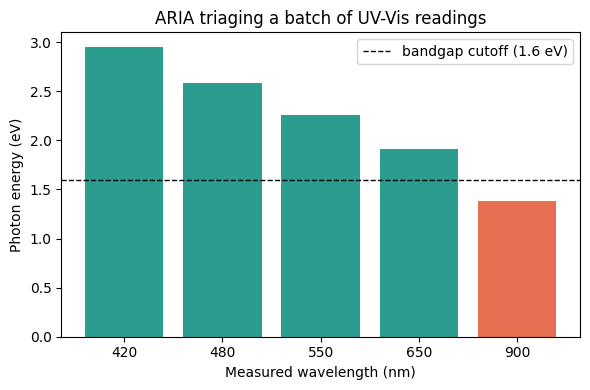

In [4]:
import matplotlib.pyplot as plt

PEROVSKITE_BANDGAP_EV = 1.6
readings_nm = [420, 480, 550, 650, 900]

results = []
for wl in readings_nm:
    r = photon_energy_eV(wl)
    energy = r["energy_eV"]
    decision = "usable" if energy >= PEROVSKITE_BANDGAP_EV else "sub-bandgap — discard"
    results.append((wl, energy, decision))
    print(f"{wl:>4} nm -> {energy:>6.3f} eV -> ARIA decision: {decision}")

wavelengths, energies, decisions = zip(*results)
colors = ["#2a9d8f" if d == "usable" else "#e76f51" for d in decisions]

plt.figure(figsize=(6, 4))
plt.bar([str(w) for w in wavelengths], energies, color=colors)
plt.axhline(PEROVSKITE_BANDGAP_EV, color="black", linestyle="--", linewidth=1, label=f"bandgap cutoff ({PEROVSKITE_BANDGAP_EV} eV)")
plt.ylabel("Photon energy (eV)")
plt.xlabel("Measured wavelength (nm)")
plt.title("ARIA triaging a batch of UV-Vis readings")
plt.legend()
plt.tight_layout()
plt.show()


## Part 4 — What is an MCP server?

So far, ARIA's tools are plain Python functions living in this notebook's process. That's fine
for a demo, but real instruments, databases, and lab software usually run as **separate
programs**, often on separate machines. If every agent had to write custom glue code for every
tool it might ever call, you'd get an N×M mess: every agent reinvented for every instrument.

**MCP (Model Context Protocol)** is an open standard — think **"USB-C for AI tools"** — that
fixes this. An **MCP server** wraps a set of capabilities behind one standard interface; any
**MCP client** (your agent) can discover and call them the same way, regardless of what
language the server is written in or where it runs. Concretely, a server exposes:

- **Tools** — callable functions, exactly like the ones in Part 1 (e.g. "compute d-spacing")
- **Prompts** — reusable prompt templates the server ships alongside its tools
- **Resources** — read-only data the server can hand back (a file, a database row, a live reading)

The client and server talk over a small JSON-RPC-based protocol — usually via **stdio** (server
runs as a subprocess) or over HTTP for a remote server. Once ARIA can speak MCP, it can call a
tool living on a colleague's XRD-analysis server exactly the same way it calls a tool defined
three cells above — the agent loop itself doesn't need to know or care where the tool lives.
This is exactly the kind of interoperability problem that comes up once you're running several
instruments, or several agents, in a self-driving lab.

We'll now build a tiny real MCP server, run it as its own process, and have ARIA talk to it.

### Setup

The official Python SDK is on PyPI. If it's not already installed, uncomment and run:

In [8]:
%pip install "mcp[cli]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.7/69.7 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 357.9/357.9 kB 10.8 MB/s eta 0:00:00


In [9]:
# %pip install "mcp[cli]" --quiet
import importlib
print("mcp SDK available:", importlib.util.find_spec("mcp") is not None)


mcp SDK available: True


## Part 5 — Build the MCP server

We write a small server script to disk — this is exactly what it'd look like living on a
separate machine next to the actual XRD instrument. It exposes the same two physics tools from
Part 1 (now served over MCP instead of called in-process) plus a **prompt template**, using the
`@mcp.tool()` / `@mcp.prompt()` decorators from the SDK's server class.

In [10]:
server_code = 'import math\nfrom mcp.server.mcpserver import MCPServer\n\nmcp = MCPServer("lab-instruments")\n\n\n@mcp.tool()\ndef photon_energy_eV(wavelength_nm: float) -> dict:\n    """Convert a UV-Vis wavelength (nm) to photon energy (eV): E = 1239.84 / lambda."""\n    energy = 1239.84 / wavelength_nm\n    return {"wavelength_nm": wavelength_nm, "energy_eV": round(energy, 4)}\n\n\n@mcp.tool()\ndef bragg_dspacing(two_theta_deg: float, wavelength_angstrom: float = 1.5406) -> dict:\n    """Convert an XRD 2*theta peak (deg) to d-spacing (Angstrom) via Bragg\'s law."""\n    theta_rad = math.radians(two_theta_deg / 2)\n    d = wavelength_angstrom / (2 * math.sin(theta_rad))\n    return {"two_theta_deg": two_theta_deg, "d_spacing_angstrom": round(d, 4)}\n\n\n@mcp.prompt()\ndef lab_assistant_prompt(instrument: str) -> str:\n    """A reusable system-prompt template the server ships with its tools."""\n    return f"You are a careful lab assistant helping analyze data from a {instrument}."\n\n\nif __name__ == "__main__":\n    import anyio\n    anyio.run(mcp.run_stdio_async)\n'

with open("lab_mcp_server.py", "w") as f:
    f.write(server_code)

print("Wrote lab_mcp_server.py — this would normally live on its own machine.")


Wrote lab_mcp_server.py — this would normally live on its own machine.


## Part 6 — Connect a real MCP client and call it

Now the important part: we start that server as its **own subprocess** and talk to it purely
through the protocol — no shared Python objects, no imports of its internals. This cell
actually launches a process, actually speaks MCP over stdio, and actually gets results back.

In [12]:
!pip install "mcp[cli]" nest_asyncio --quiet

server_code = '''import math
from mcp.server.mcpserver import MCPServer

mcp = MCPServer("lab-instruments")


@mcp.tool()
def photon_energy_eV(wavelength_nm: float) -> dict:
    """Convert a UV-Vis wavelength (nm) to photon energy (eV): E = 1239.84 / lambda."""
    energy = 1239.84 / wavelength_nm
    return {"wavelength_nm": wavelength_nm, "energy_eV": round(energy, 4)}


@mcp.tool()
def bragg_dspacing(two_theta_deg: float, wavelength_angstrom: float = 1.5406) -> dict:
    """Convert an XRD 2*theta peak (deg) to d-spacing (Angstrom) via Bragg's law."""
    theta_rad = math.radians(two_theta_deg / 2)
    d = wavelength_angstrom / (2 * math.sin(theta_rad))
    return {"two_theta_deg": two_theta_deg, "d_spacing_angstrom": round(d, 4)}


@mcp.prompt()
def lab_assistant_prompt(instrument: str) -> str:
    """A reusable system-prompt template the server ships with its tools."""
    return f"You are a careful lab assistant helping analyze data from a {instrument}."


if __name__ == "__main__":
    import anyio
    anyio.run(mcp.run_stdio_async)
'''

with open("lab_mcp_server.py", "w") as f:
    f.write(server_code)

print("Wrote lab_mcp_server.py")

Wrote lab_mcp_server.py


In [14]:
import nest_asyncio
nest_asyncio.apply()

import asyncio
import subprocess
from mcp import StdioServerParameters, ClientSession
from mcp.client.stdio import stdio_client

async def main():
    server_params = StdioServerParameters(command="python3", args=["lab_mcp_server.py"])

    # errlog=subprocess.DEVNULL avoids Colab's fake sys.stderr, which has no
    # real file descriptor and crashes subprocess.Popen's stderr handling.
    async with stdio_client(server_params, errlog=subprocess.DEVNULL) as (read, write):
        async with ClientSession(read, write) as session:
            await session.initialize()

            tool_list = await session.list_tools()
            prompt_list = await session.list_prompts()
            print("Tools exposed by the server:", [t.name for t in tool_list.tools])
            print("Prompts exposed by the server:", [p.name for p in prompt_list.prompts])

            r1 = await session.call_tool("photon_energy_eV", {"wavelength_nm": 517})
            print("\nphoton_energy_eV(517 nm) over MCP ->", r1.content[0].text)

            r2 = await session.call_tool("bragg_dspacing", {"two_theta_deg": 28.4})
            print("bragg_dspacing(28.4 deg) over MCP  ->", r2.content[0].text)

            p1 = await session.get_prompt("lab_assistant_prompt", {"instrument": "XRD diffractometer"})
            print("\nPrompt template filled by the server:", p1.messages[0].content.text)

asyncio.run(main())

Tools exposed by the server: ['photon_energy_eV', 'bragg_dspacing']
Prompts exposed by the server: ['lab_assistant_prompt']

photon_energy_eV(517 nm) over MCP -> {
  "wavelength_nm": 517.0,
  "energy_eV": 2.3981
}
bragg_dspacing(28.4 deg) over MCP  -> {
  "two_theta_deg": 28.4,
  "d_spacing_angstrom": 3.1401
}

Prompt template filled by the server: You are a careful lab assistant helping analyze data from a XRD diffractometer.


## Part 7 — Route the *same* agent loop through MCP

This is the payoff: `run_agent` from Part 3 never has to change. We only need a thin wrapper
that executes a tool call through the MCP session instead of a local dict — same brain, same
loop shape, tools now genuinely running in a separate process.

In [18]:
import subprocess

async def run_agent_over_mcp(question: str, brain, session, max_steps: int = 4, verbose: bool = True) -> str:
    history = []

    for step in range(max_steps):
        decision = brain.decide(question, history)

        if decision["action"] == "final_answer":
            if verbose:
                print(f"[step {step}] FINAL ANSWER: {decision['answer']}")
            return decision["answer"]

        tool_name = decision["tool"]
        args = decision.get("args", {})

        if verbose:
            print(f"[step {step}] Calling MCP tool '{tool_name}' with args {args}")

        mcp_result = await session.call_tool(tool_name, args)
        result_text = mcp_result.content[0].text
        history.append({"tool": tool_name, "args": args, "result": result_text})

        if verbose:
            print(f"[step {step}]   -> {result_text}")

    return "Agent stopped: reached max_steps without a final answer."


async def main():
    server_params = StdioServerParameters(command="python3", args=["lab_mcp_server.py"])
    async with stdio_client(server_params, errlog=subprocess.DEVNULL) as (read, write):
        async with ClientSession(read, write) as session:
            await session.initialize()
            await run_agent_over_mcp("The absorption onset is at 550 nm, what's the photon energy?", brain, session)
            print()
            await run_agent_over_mcp("The XRD peak is at 2theta = 28.4 degrees, what's the d-spacing?", brain, session)

asyncio.run(main())

[step 0] Calling MCP tool 'photon_energy_eV' with args {'wavelength_nm': 550.0}
[step 0]   -> {
  "wavelength_nm": 550.0,
  "energy_eV": 2.2543
}
[step 1] FINAL ANSWER: Using photon_energy_eV, I found: {
  "wavelength_nm": 550.0,
  "energy_eV": 2.2543
}

[step 0] Calling MCP tool 'bragg_dspacing' with args {'two_theta_deg': 28.4}
[step 0]   -> {
  "two_theta_deg": 28.4,
  "d_spacing_angstrom": 3.1401
}
[step 1] FINAL ANSWER: Using bragg_dspacing, I found: {
  "two_theta_deg": 28.4,
  "d_spacing_angstrom": 3.1401
}


## Part 8 — Upgrading the brain: let Gemini control the agent

Last swap: replace `RuleBasedBrain` with a real LLM, using the exact same `decide()` interface —
neither `run_agent` nor `run_agent_over_mcp` changes at all. This is also where the three prompt
types from Part 0 come back explicitly: the **system prompt** below tells Gemini its role and
output format, the **tool descriptions** are handed to it verbatim, and the **user prompt** is
whatever question we ask.

### Setup
1. Get a free Gemini API key: https://aistudio.google.com/app/apikey
2. Install the SDK: `pip install google-genai --break-system-packages`
3. Paste your key into `GEMINI_API_KEY` below (or set it as an environment variable and leave the string empty)

Without a key, this degrades gracefully back to `RuleBasedBrain` — the rest of the notebook still works.

In [ ]:
import os
import json

GEMINI_API_KEY = "your key here"  # <-- paste your key here, or leave blank to use an env var
GEMINI_API_KEY = GEMINI_API_KEY or os.environ.get("GEMINI_API_KEY", "")

_gemini_ready = False
_import_error = None
try:
    from google import genai as genai_sdk
    if GEMINI_API_KEY:
        _gemini_client = genai_sdk.Client(api_key=GEMINI_API_KEY)
        _gemini_ready = True
except ImportError as e:
    _import_error = e

print("google-genai installed:", _import_error is None)
print("API key provided:", bool(GEMINI_API_KEY))
print("Gemini brain ready to use:", _gemini_ready)


google-genai installed: True
API key provided: True
Gemini brain ready to use: True


In [21]:
SYSTEM_PROMPT = '''You are the decision-making brain of a lab-assistant agent named ARIA. You do NOT
answer questions directly using your own knowledge if a tool can answer them. On every turn you must
reply with ONLY a single JSON object (no markdown fences, no commentary), in exactly one of these two
shapes:

{"action": "tool_call", "tool": "<tool name>", "args": {<tool args>}}
{"action": "final_answer", "answer": "<your answer as a string>"}

Available tools:
{tool_list}

Rules:
- If a tool result is already available in the conversation history, use it to give a final_answer.
- Only call a tool that exists in the list above, with exactly the argument names shown.
- Never call more than one tool per turn.
'''

class GeminiBrain:
    '''Same interface as RuleBasedBrain.decide(), but a real LLM makes the call.'''

    def __init__(self, model_name: str = "gemini-2.5-flash", tools=TOOLS):
        self.client = _gemini_client
        self.model_name = model_name
        tool_list = "\n".join(f"- {name}: {spec['description']}" for name, spec in tools.items())
        self.system_prompt = SYSTEM_PROMPT.replace("{tool_list}", tool_list)  # <- the system prompt

    def decide(self, question: str, history: list) -> dict:  # `question` is the user prompt
        history_text = "\n".join(
            f"Called {h['tool']}({h['args']}) -> {h['result']}" for h in history
        ) or "(no tool calls yet)"

        prompt = f"{self.system_prompt}\n\nUser question: {question}\n\nHistory so far:\n{history_text}\n\nYour JSON decision:"

        response = self.client.models.generate_content(model=self.model_name, contents=prompt)
        text = response.text.strip().strip("`")
        if text.lower().startswith("json"):
            text = text[4:].strip()

        try:
            return json.loads(text)
        except json.JSONDecodeError:
            return {"action": "final_answer", "answer": f"(Could not parse Gemini output, raw reply: {text})"}


if _gemini_ready:
    gemini_brain = GeminiBrain()
    print("GeminiBrain is live — it will make the decisions below.")
else:
    print("No usable Gemini key/library detected — the demo below will fall back to RuleBasedBrain.")
    print("Add a key above and re-run this cell + the next one to see Gemini drive the agent.")

GeminiBrain is live — it will make the decisions below.


In [22]:
active_brain = gemini_brain if _gemini_ready else brain
print(f"Active brain: {type(active_brain).__name__}\n")

for q in [
    "The absorption onset is at 480 nm, what photon energy is that?",
    "Can you explain what XRD is?",
    "What time is it right now?",
]:
    print("=" * 70)
    print("QUESTION:", q)
    run_agent(q, active_brain)
    print()


Active brain: GeminiBrain

QUESTION: The absorption onset is at 480 nm, what photon energy is that?
[step 0] Calling tool 'photon_energy_eV' with args {'wavelength_nm': 480.0}
[step 0]   -> {'ok': True, 'wavelength_nm': 480.0, 'energy_eV': 2.583}
[step 1] FINAL ANSWER: The photon energy at an absorption onset of 480 nm is 2.583 eV.

QUESTION: Can you explain what XRD is?
[step 0] Calling tool 'materials_database_lookup' with args {'query': 'XRD'}
[step 0]   -> {'ok': True, 'term': 'xrd', 'definition': 'X-ray diffraction — a technique that measures how X-rays scatter off a crystal lattice, used to determine lattice spacing and identify crystal structure.'}
[step 1] FINAL ANSWER: XRD stands for X-ray diffraction. It's a technique that measures how X-rays scatter off a crystal lattice, used to determine lattice spacing and identify crystal structure.

QUESTION: What time is it right now?
[step 0] Calling tool 'experiment_timestamp' with args {}
[step 0]   -> {'ok': True, 'result': 'Wednes

## Exercises

1. **Add a fifth tool.** Write `tauc_bandgap(absorption_edge_nm: float) -> dict` that reuses
   `photon_energy_eV` internally and just labels the result "estimated optical bandgap." Add it
   to `TOOLS` and extend `RuleBasedBrain.decide`. Notice `run_agent` needs zero changes.
2. **Multi-tool question.** Ask the rule-based brain something needing two tools in one question
   (e.g. "the peak is at 2theta=31.7 and the absorption onset is 480 nm"). Why does it fail? What
   would you change in the brain or the loop to support it?
3. **Extend the MCP server.** Add `materials_database_lookup` as a third `@mcp.tool()` in
   `lab_mcp_server.py`, then call it through `session.call_tool` in Part 6. You changed nothing
   about the *client* code apart from the tool name and args — that's the point of the protocol.
4. **Access control (ties back to Lecture 1).** Suppose one MCP tool were `move_stage(x, y)` on a
   real XRD sample stage instead of a harmless calculation. What would you add — on the client, on
   the server, or both — before executing a tool call to make that safe? Sketch the check.
5. **Compare brains.** Run the same five questions through `RuleBasedBrain` and `GeminiBrain` and
   compare. Where do they disagree, and why?


## Recap

You built, end to end:
- **Prompts** — system prompt, user prompt, and tool descriptions, and saw all three used twice (by an `if/elif` brain and by Gemini)
- **Tools** — real physics functions a characterization lab actually uses
- **A brain interface** — `decide(question, history) -> {"action": ...}`
- **An agent loop** — the reusable engine, unchanged whether tools run locally, over MCP, or under Gemini's control
- **A real decision** — ARIA triaging a batch of readings against a bandgap threshold, not just answering questions
- **MCP** — built a real server, ran it as its own process, and called it over the protocol
- **A real LLM in the loop** — Gemini making the same kind of decision, through the same interface

Lecture 2 builds on this: more rigorous prompt engineering, retrieval-augmented tools, MCP
resources and remote servers, and multi-agent patterns where several of these loops — possibly
each talking to a different instrument's MCP server — coordinate with each other.
